# a) Fuel development over time

This notebook explores how fuel types change over time in Switzerland, with a line chart and an area chart. It uses the shared preparation pipeline and visual encoding.

In [139]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter, MultipleLocator


from preparation import PreparSwissVehicle


with open("./shared_configs.json", encoding="utf-8") as f:
    cfg = json.load(f)

output_dir = Path(cfg["output_dir"])
figure_size = cfg["figure_size"]
colors_new = cfg["fuel_category_colors"]
saving_cfg = cfg["saving_config"]
data_source_cfg = cfg["data_source"]  
title_cfg = cfg["title_style"]
subtitle_cfg = cfg["subtitle_style"]

prep = PreparSwissVehicle()
plot_df = prep.aggregate_by_year().copy()
plot_df.sort_values(["FuelCategory", "YEAR"], inplace=True) 
plot_df.head()

,YEAR,FuelCategory,OBS_VALUE
0,2016,BEV,9118
5,2017,BEV,12807
10,2018,BEV,17331
15,2019,BEV,26333
20,2020,BEV,41362


## Drafts for Data Viz Clinic

The following two plots were created for the Data Viz Clinic at the beginning of the project. 

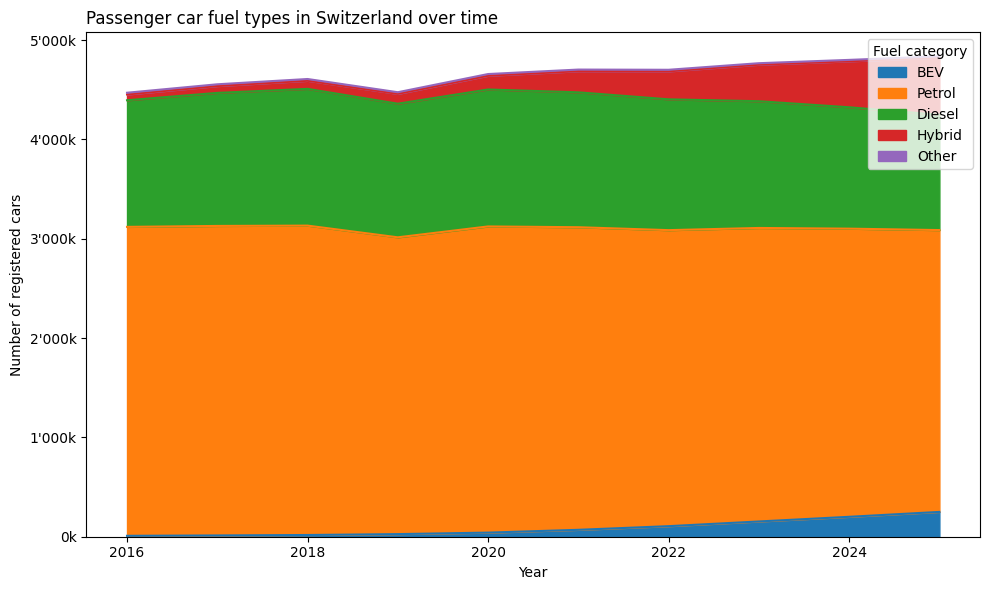

Saved: ..\docs\graphic_own\vis_a_area_0.png


In [140]:
pivot_area = prep.to_pivot(plot_df, index_col="YEAR").sort_index()

fig, ax = plt.subplots(figsize=figure_size)
pivot_area.plot.area(ax=ax)

ax.ticklabel_format(style="plain", axis="y")

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1000:,.0f}k".replace(",", "'")))
ax.set_ylabel("Number of registered cars")
ax.set_xlabel("Year")
ax.legend(title="Fuel category", loc="upper right")

ax.set_title("Passenger car fuel types in Switzerland over time", loc="left")
plt.tight_layout()

area_path = output_dir / "vis_a_area_0.png"
plt.savefig(area_path, **saving_cfg)
plt.show()

print(f"Saved: {area_path}")

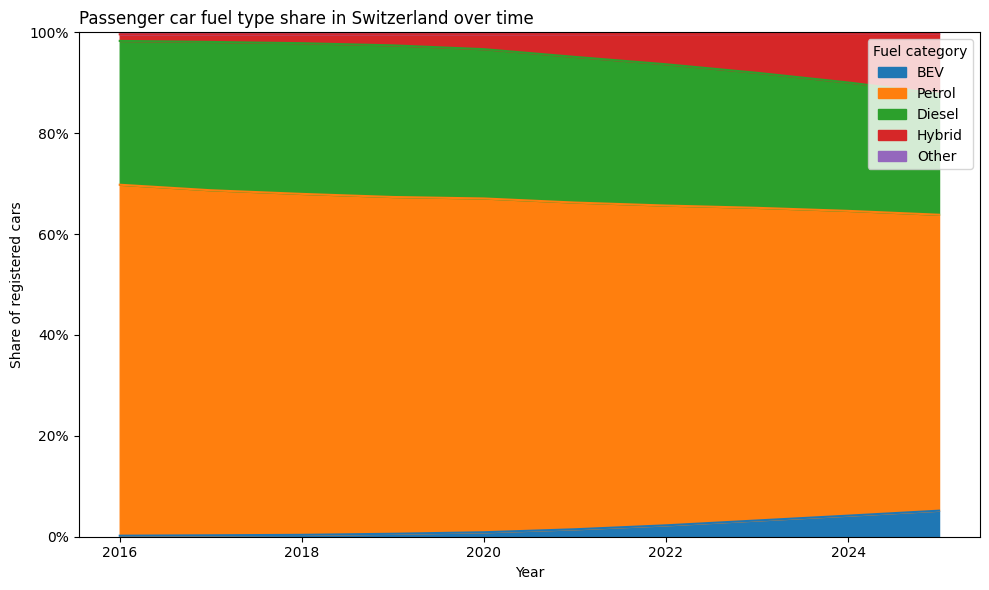

Saved: ..\docs\graphic_own\vis_a_area_pct_0.png


In [141]:
pivot_pct = pivot_area.div(pivot_area.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=figure_size)
pivot_pct.plot.area(ax=ax)

ax.set_xlabel("Year")

ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_ylabel("Share of registered cars")
ax.legend(title="Fuel category", loc="upper right")

ax.set_title("Passenger car fuel type share in Switzerland over time", loc="left")
plt.tight_layout()

area_pct_path = output_dir / "vis_a_area_pct_0.png"
plt.savefig(area_pct_path, **saving_cfg)
plt.show()

print(f"Saved: {area_pct_path}")

## Staked Area plot with absolute numbers

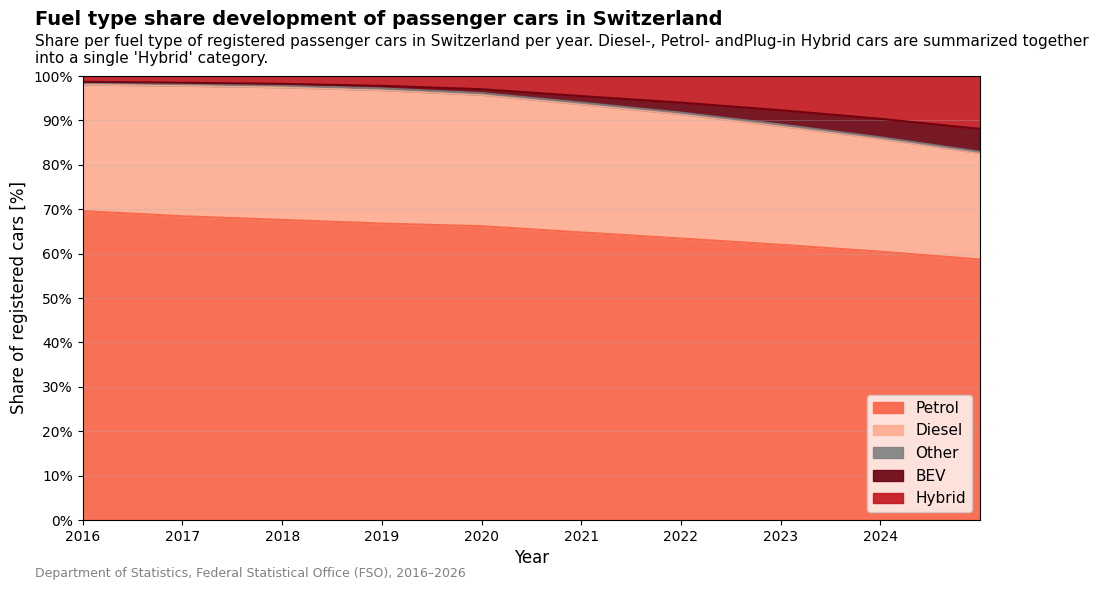

Saved: ..\docs\graphic_own\vis_a_area_pct_1.png


In [142]:
plot_order = ["Petrol", "Diesel", "Other", "BEV", "Hybrid"]
pivot_pct = pivot_area.div(pivot_area.sum(axis=1), axis=0) * 100
pivot_pct = pivot_pct[plot_order]


fig, ax = plt.subplots(figsize=figure_size)
pivot_pct.plot.area( ax=ax,alpha=0.9,color=[colors_new[c] for c in plot_order],)

ax.set_xlim(2016, 2025)
ax.set_xticks(range(2016, 2025))
ax.yaxis.set_major_formatter(PercentFormatter())
ax.yaxis.set_major_locator(plt.MultipleLocator(10))
ax.set_ylim(0, 100)
ax.grid(alpha=0.3, axis="y")


ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Share of registered cars [%]", fontsize=12)

fig.text(s="Fuel type share development of passenger cars in Switzerland", **title_cfg)

fig.text(s = "Share per fuel type of registered passenger cars in Switzerland per year. Diesel-, Petrol- and" \
"Plug-in Hybrid cars are summarized together\ninto a single 'Hybrid' category.",
         **subtitle_cfg)

fig.text(**data_source_cfg)

ax.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.subplots_adjust(**cfg["plot_space"])


area_pct_path = output_dir / "vis_a_area_pct_1.png"
plt.savefig(area_pct_path, **saving_cfg)
plt.show()

print(f"Saved: {area_pct_path}")

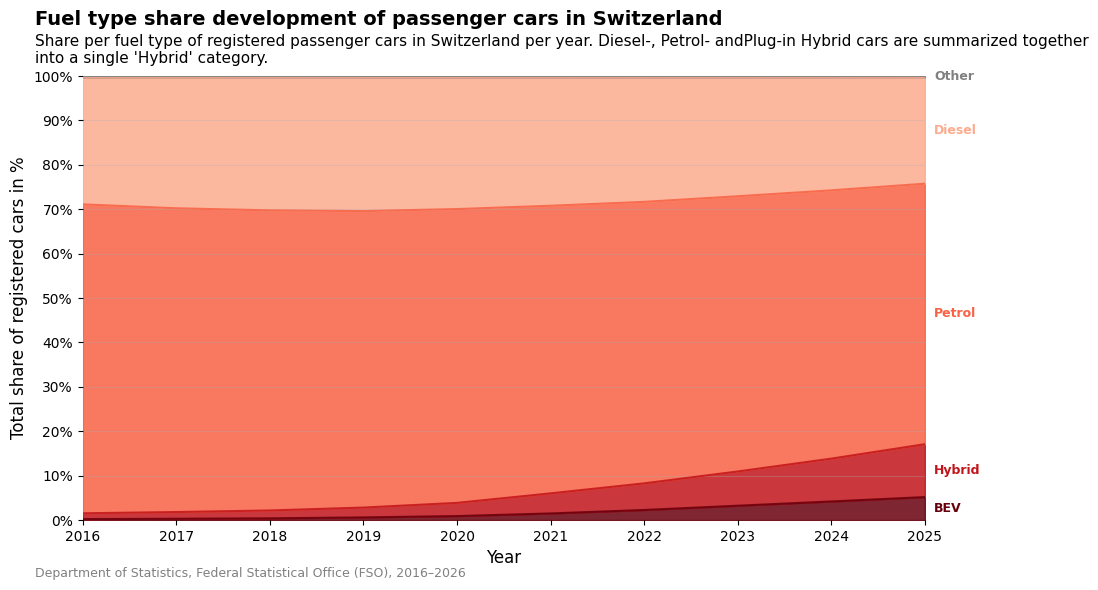

Saved: ..\docs\graphic_own\vis_a_area_pct_2.png


In [143]:
plot_order = ["BEV", "Hybrid", "Petrol", "Diesel", "Other"]

pivot_pct = pivot_area.div(pivot_area.sum(axis=1), axis=0) * 100
pivot_pct = pivot_pct[plot_order]

fig, ax = plt.subplots(figsize=figure_size)
pivot_pct.plot.area(ax=ax,alpha=0.85, color=[colors_new[c] for c in plot_order])

cumulative_sum = pivot_pct.cumsum(axis=1)


x_min = pivot_pct.index.min()
x_max = pivot_pct.index.max()

ax.set_xlim(x_min, x_max)
ax.set_xticks(range(x_min, x_max + 1))

ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.yaxis.set_major_locator(plt.MultipleLocator(10))

ax.legend().set_visible(False)   


# Uggly hack for label spacing
# draw grid before widening xlim to keep it contained
ax.grid(alpha=0.3, axis="y")


# Labels outside axes
cumulative_at_end = cumulative_sum.iloc[-1]
for i, col in enumerate(plot_order):
    top = cumulative_at_end[col]
    bottom = cumulative_at_end[plot_order[i - 1]] if i > 0 else 0
    mid = (top + bottom) / 2
    ax.text(x_max + 0.1, mid, col,
            color=colors_new[col],
            va="center", ha="left", fontsize=9, fontweight="bold",
            clip_on=False)        # allows drawing outside axes bounds
    
for spine in ax.spines.values():
    spine.set_visible(False)


ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Total share of registered cars in %", fontsize=12)

fig.text(s= "Fuel type share development of passenger cars in Switzerland", **title_cfg)

fig.text(s = "Share per fuel type of registered passenger cars in Switzerland per year. Diesel-, Petrol- and" \
"Plug-in Hybrid cars are summarized together\ninto a single 'Hybrid' category.",
         **subtitle_cfg)


fig.text(**data_source_cfg)

plt.tight_layout()
plt.subplots_adjust(**cfg["plot_space"])  

area_pct_path = output_dir / "vis_a_area_pct_2.png"
plt.savefig(area_pct_path, **saving_cfg)
plt.show()

print(f"Saved: {area_pct_path}")


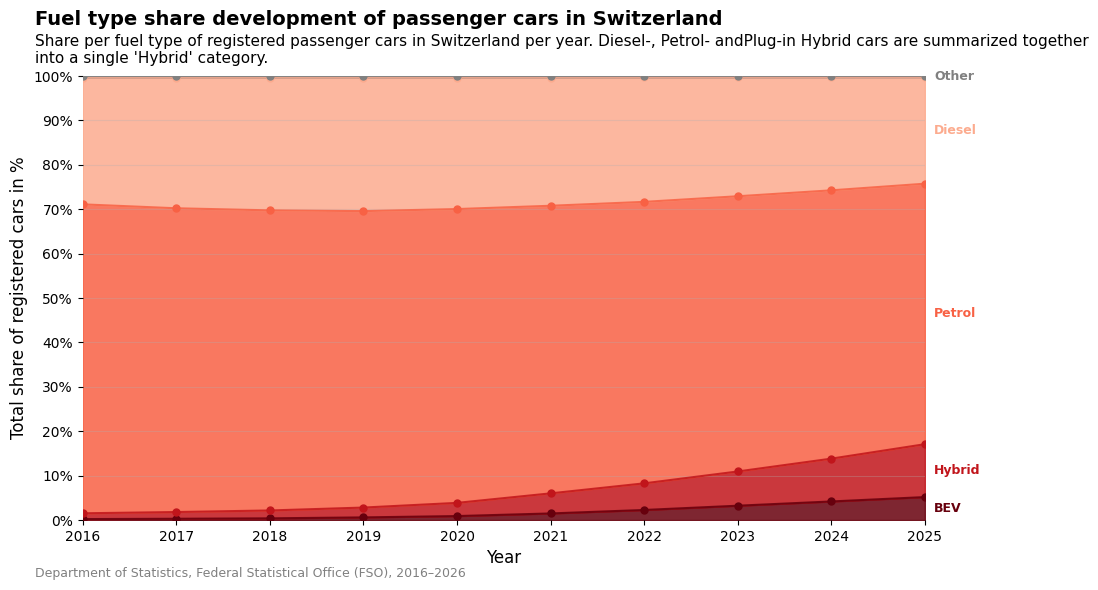

Saved: ..\docs\graphic_own\vis_a_area_pct_3.png


In [144]:
plot_order = ["BEV", "Hybrid", "Petrol", "Diesel", "Other"]

pivot_pct = pivot_area.div(pivot_area.sum(axis=1), axis=0) * 100
pivot_pct = pivot_pct[plot_order]

fig, ax = plt.subplots(figsize=figure_size)
pivot_pct.plot.area(ax=ax,alpha=0.85, color=[colors_new[c] for c in plot_order])

cumulative_sum = pivot_pct.cumsum(axis=1)

for col in plot_order:
    ax.plot(cumulative_sum.index,
        cumulative_sum[col],
        color=colors_new[col],
        marker="o",
        markersize=5,
        linewidth=0,
    )

x_min = pivot_pct.index.min()
x_max = pivot_pct.index.max()

ax.set_xlim(x_min, x_max)
ax.set_xticks(range(x_min, x_max + 1))

ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.yaxis.set_major_locator(plt.MultipleLocator(10))

ax.legend().set_visible(False)   


# Uggly hack for label spacing
# draw grid before widening xlim to keep it contained
ax.grid(alpha=0.3, axis="y")


# Labels outside axes
cumulative_at_end = cumulative_sum.iloc[-1]
for i, col in enumerate(plot_order):
    top = cumulative_at_end[col]
    bottom = cumulative_at_end[plot_order[i - 1]] if i > 0 else 0
    mid = (top + bottom) / 2
    ax.text(x_max + 0.1, mid, col,
            color=colors_new[col],
            va="center", ha="left", fontsize=9, fontweight="bold",
            clip_on=False)        # allows drawing outside axes bounds
    
for spine in ax.spines.values():
    spine.set_visible(False)


ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Total share of registered cars in %", fontsize=12)

fig.text(s= "Fuel type share development of passenger cars in Switzerland", **title_cfg)

fig.text(s = "Share per fuel type of registered passenger cars in Switzerland per year. Diesel-, Petrol- and" \
"Plug-in Hybrid cars are summarized together\ninto a single 'Hybrid' category.",
         **subtitle_cfg)


fig.text(**data_source_cfg)

plt.tight_layout()
plt.subplots_adjust(**cfg["plot_space"])  

area_pct_path = output_dir / "vis_a_area_pct_3.png"
plt.savefig(area_pct_path, **saving_cfg)
plt.show()

print(f"Saved: {area_pct_path}")


## Staked area plot

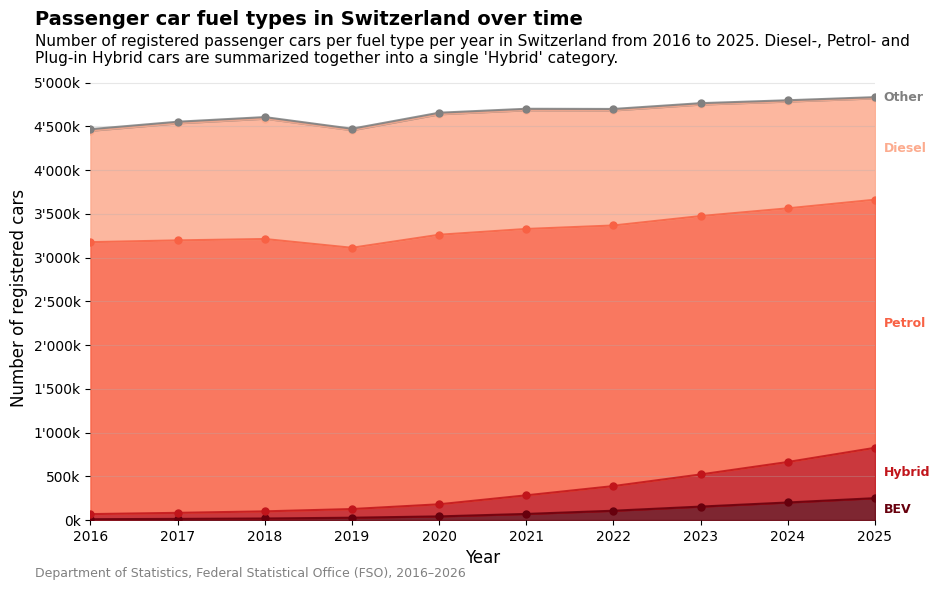

Saved: ..\docs\graphic_own\vis_a_area_1.png


In [145]:
pivot_area_ordered = pivot_area[plot_order]

fig, ax = plt.subplots(figsize=figure_size)
pivot_area_ordered.plot.area(
    ax=ax,
    alpha=0.85,
    color=[colors_new[c] for c in plot_order],
)

cumulative_sum = pivot_area_ordered.cumsum(axis=1)
for col in plot_order:
    ax.plot(
        cumulative_sum.index,
        cumulative_sum[col],
        color=colors_new[col],
        marker="o",
        markersize=5,
        linewidth=0,
    )

x_min = pivot_area_ordered.index.min()
x_max = pivot_area_ordered.index.max()

ax.set_xlim(x_min, x_max)
ax.set_xticks(range(x_min, x_max + 1))
ax.ticklabel_format(style="plain", axis="y")
ax.yaxis.set_major_locator(MultipleLocator(500_000))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1000:,.0f}k".replace(",", "'")))

ax.grid(alpha=0.3, axis="y")
ax.set_xlim(x_min, x_max + 2)        # extend for labels

fig.text(s="Passenger car fuel types in Switzerland over time", **title_cfg)

fig.text(s = "Number of registered passenger cars per fuel type per year in Switzerland from 2016 to 2025. "
         "Diesel-, Petrol- and\nPlug-in Hybrid cars are summarized together into a single 'Hybrid' category.",
         **subtitle_cfg)

fig.text(**data_source_cfg)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Number of registered cars", fontsize=12)

ax.set_xlim(x_min, x_max)
ax.grid(alpha=0.3, axis="y")
ax.legend().set_visible(False)

# Labels outside axes at midpoint of each band
cumulative_at_end = cumulative_sum.iloc[-1]
for i, col in enumerate(plot_order):
    top = cumulative_at_end[col]
    bottom = cumulative_at_end[plot_order[i - 1]] if i > 0 else 0
    mid = (top + bottom) / 2
    ax.text(x_max + 0.1, mid, col,
            color=colors_new[col],
            va="center", ha="left", fontsize=9, fontweight="bold",
            clip_on=False)

plt.tight_layout()
plt.subplots_adjust(**cfg["plot_space"], right=0.88)

area_path = output_dir / "vis_a_area_1.png"
plt.savefig(area_path, **saving_cfg)
plt.show()

print(f"Saved: {area_path}")
